<a href="https://colab.research.google.com/github/emmagiometti/A2026_Intro_Python/blob/main/1_3_exercises_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.3-numpy-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [1]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"gsw": "gsw", "pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Import numpy as `np`, and encode units in your variable names.

## Exercise 1: Create and inspect

Build the following 3×4 field of temperatures (°C) as a numpy array:

`5.2 4.8 6.1 3.9 1.3 0.5 -0.8 -1.2 -2.6 -3.1 -1.9 0.2`

Print its `shape`, `ndim`, and `dtype`, and its overall mean rounded to two decimals.
Then create, and print, three arrays of the same shape without typing the shape out by hand:
all ones, a uniform reference field of 15.0 °C, and random values in [0, 1).

In [2]:
# Your solution here
import numpy as np
temps_C = np.array([[5.2, 4.8, 6.1],
                    [3.9, 1.3, 0.5],
                    [-0.8, -1.2, -2.6],
                    [-3.1, -1.9, 0.2]])

#printing shape, ndim, and dtype
print(temps_C)
print("shape:", temps_C.shape, "| ndim:", temps_C.ndim, "| dtype:", temps_C.dtype)

#ndim = number of axes !! this one is 2 because it is a 2D field, with rows and columns

#creating 3 arrays of the same shape (3 rows 4 columns)

#all ones
print(np.ones((4,3)))

#uniform reference field of 15.0 C
print(np.full((4, 3), 15.0))


#random values in [0,1)
print(np.random.random((4,3)))



[[ 5.2  4.8  6.1]
 [ 3.9  1.3  0.5]
 [-0.8 -1.2 -2.6]
 [-3.1 -1.9  0.2]]
shape: (4, 3) | ndim: 2 | dtype: float64
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
[[15. 15. 15.]
 [15. 15. 15.]
 [15. 15. 15.]
 [15. 15. 15.]]
[[0.23853673 0.66713776 0.541671  ]
 [0.84846694 0.42686145 0.86388019]
 [0.4256232  0.10374896 0.5522635 ]
 [0.97911047 0.46890242 0.68817345]]


## Exercise 2: Index and slice

Given

```python
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])
```

print the last row, the first column, and the 2×2 sub-block formed by the first two rows and the last two columns.

Finally, take a slice of the first row, change its first element to `99.0`, and print the original array. Then repeat using `.copy()`. Explain the difference in a comment.

In [3]:
# Your solution here
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])
#printing last row (calls last row and all columns of last row)
print(a[-1, :])

#print first column, all rows in first column
print(a[:,0])

#[row, col]
print(a[0:2, 2:4])

[ 9. 10. 11. 12.]
[1. 5. 9.]
[[3. 4.]
 [7. 8.]]


## Exercise 3: Masking and np.where

Given

```python
temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])
```

print the values that exceed 10 °C, their mean, and the percentage of the field they make up.
Then build a clipped field in which every value below 0 °C is set to 0, using `np.where`.

In [4]:
# Your solution here
temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])

warm = temp_celsius[temp_celsius > 10]
print("mean warm:", int(warm.mean()))

#percentage of field made up
print("field percentage:", (warm.size / temp_celsius.size) * 100, "%")

#clipped field replaces values below 0C with 0 (first zero is the condition, second zero tells what to replace the numbers with?)
clipped_field = np.where(temp_celsius < 0, 0, temp_celsius)
print(clipped_field)

mean warm: 12
field percentage: 33.33333333333333 %
[[ 0.  12.   3. ]
 [ 8.   0.  15. ]
 [ 4.   0.5 11. ]]


## Exercise 4: Broadcasting and grids

Given the field below, add a per-column offset (length 4) to every row, and separately add a per-row offset (length 3) to every column.

```python
field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])
```

Then build a grid of 4 evenly spaced longitudes from 6 to 9 °E and 3 evenly spaced latitudes
from 46 to 47 °N, so that it has the same shape as `field`. On that grid, compute a synthetic temperature
field that is 15.0 °C at (6 °E, 46 °N), cools by 0.6 °C per degree of latitude northward, and warms
by 0.2 °C per degree of longitude eastward. Compute it twice, once from the 2D arrays that
`np.meshgrid` returns and once by broadcasting the 1D latitudes and longitudes directly, and
confirm with `np.allclose` that the two agree.

In [5]:
# Your solution here
field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])

print(field.shape)


#adding per-column offset
#no need to reshape since their trailing dimensions match

field_col_off = field + col_offset
  #broadcasts 1D array of length 4 to match field's shape on all rows
print("Field with column offset:")
print(field_col_off)
print("Shape:", field_col_off.shape)

#adding per-row offset to each column
print(row_offset[:, None].shape)
newfield = field_col_off + row_offset[:, None]
print("Field with row offset:")
print(newfield)
print("Shape:", newfield.shape)

(3, 4)
Field with column offset:
[[ 1.  3.  5.  7.]
 [ 5.  7.  9. 11.]
 [ 9. 11. 13. 15.]]
Shape: (3, 4)
(3, 1)
Field with row offset:
[[11. 13. 15. 17.]
 [25. 27. 29. 31.]
 [39. 41. 43. 45.]]
Shape: (3, 4)


## Exercise 5: Axis reductions

Given seasonal mean temperatures at three stations, one row per station and one column per season
(winter, spring, summer, autumn):

```python
seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])
```

print the annual mean at each station and the index of each station's warmest season. Then find the
coldest value in each season twice, once with the method and once with the numpy function, and
confirm they agree.

Finally, given four days of rainfall at two stations, one row per station,

```python
rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])
```

use `cumsum` along the right axis to get the rain to date. Print the index of the station that was
wetter after the second day and the index of the station that was wetter after all four. Are they
the same station?

In [6]:
seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])

# mean at each station:
print("mean per row:", seasonal_celsius.mean(axis=1))

# index of each station's warmest season:
print("warmest season index per station:", seasonal_celsius.argmax(axis=1))

# coldest value in each season (min along axis 0):
coldest_method = seasonal_celsius.min(axis=0)
coldest_function = np.min(seasonal_celsius, axis=0)

print("Coldest via method:", coldest_method)

print("Coldest via numpy function:", coldest_function)
print("Confirm they agree:", np.all(coldest_method == coldest_function))

rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])

rain_todate_mm = np.cumsum(rain_mm, axis=1)
print("Rain to date:\n", rain_todate_mm)

# Wetter station index after the second day (column index 1)
wetter_day_2 = np.argmax(rain_todate_mm[:, 1])
# Wetter station index after all four days (column index 3)
wetter_day_4 = np.argmax(rain_todate_mm[:, 3])

print("Wetter station index after 2nd day:", wetter_day_2)
print("Wetter station index after 4th day:", wetter_day_4)
print("Are they the same station?", wetter_day_2 == wetter_day_4)

mean per row: [10.125  7.65  12.1  ]
warmest season index per station: [2 2 2]
Coldest via method: [-1.5  7.2 16.9  8. ]
Coldest via numpy function: [-1.5  7.2 16.9  8. ]
Confirm they agree: True
Rain to date:
 [[ 0.   6.2  7.3  7.3]
 [ 2.4  2.4  2.4 10.7]]
Wetter station index after 2nd day: 0
Wetter station index after 4th day: 1
Are they the same station? False


## Exercise 6: Missing data and interpolation

Given hourly air temperatures with a gap of two readings,

```python
temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])
```

fill the gap by linear interpolation against the integer index. Then print the NaN-aware mean of the
original series and the ordinary mean of the filled one. The two differ; say in a comment why.

In [7]:
# Linear interpolation with np.interp
temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])
profile = temp_celsius.copy()

x = np.arange(profile.size)
known_mask = ~np.isnan(profile)

# Interpolate only the missing values
profile[~known_mask] = np.interp(x[~known_mask], x[known_mask], temp_celsius[known_mask])

print("Original series:  ", temp_celsius)
print("Filled series:    ", profile)

# Print NaN-aware mean of original series and ordinary mean of filled series
nan_aware_mean = np.nanmean(temp_celsius)
ordinary_mean = np.mean(profile)

print("NaN-aware mean:", nan_aware_mean)
print("Ordinary mean: ", ordinary_mean)

# Why they differ:
# The NaN-aware mean (15.5) ignores the gap entirely. The filled series contains
# the interpolated values (15.0 and 16.5). Since both of these interpolated values
# are higher than the average of the other values (except 18.0 and 18.5),
# their inclusion pulls the ordinary mean of the filled series up to ~15.58.

Original series:   [12.  13.5  nan  nan 18.  18.5]
Filled series:     [12.  13.5 15.  16.5 18.  18.5]
NaN-aware mean: 15.5
Ordinary mean:  15.583333333333334


## Exercise 7: Avoid the dtype trap

An assistant wrote this function to compute each cell's share of the total rainfall in an integer
field of rain-gauge readings:

```python
def rain_share(rain_mm):
    share = np.zeros_like(rain_mm)
    share[:] = rain_mm / rain_mm.sum()
    return share

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])
```

Call it and print the result. Explain in a comment why every share is 0, then fix the function
twice: once keeping the preallocation but passing `dtype=float` to `np.zeros_like`, and once
without preallocating at all. Confirm that each fixed version returns a float array whose shares
sum to 1.

In [8]:
# Your solution here
def rain_share(rain_mm):
    share = np.zeros_like(rain_mm)
    share[:] = rain_mm / rain_mm.sum()
    return share
  #inherits integer type


rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])
print("input dtype:", rain_mm.dtype)
#rint(rain_share(rain_mm))
print("Original function output (integer truncation yields zeros):\n", rain_share(rain_mm))

#passing dtype = float
def rain_share2(rain_mm):
    # subtract the mean into a preallocated array (as an assistant returned it)
    result = np.zeros_like(rain_mm, dtype=float)        # inherits field's dtype!
    result[:] = rain_mm - rain_mm.mean()
    return result

#without preallocating
def rain_share3(rain_mm):
    # let numpy promote to float; no wrong-dtype preallocation
    return rain_mm / rain_mm.mean()

# Verification
result2 = rain_share2(rain_mm)
result3 = rain_share3(rain_mm)

print("\nFix 1 (preallocated with float dtype):\n", result2)
print("Fix 1 Sum:", result2.sum(), "| Output dtype:", result2.dtype)

print("\nFix 2 (direct without preallocation):\n", result3)
print("Fix 2 Sum:", result3.sum(), "| Output dtype:", result3.dtype)

input dtype: int64
Original function output (integer truncation yields zeros):
 [[0 0 0]
 [0 0 0]
 [0 0 0]]

Fix 1 (preallocated with float dtype):
 [[-2.77777778 -0.77777778  2.22222222]
 [-1.77777778 -2.77777778  5.22222222]
 [ 0.22222222  1.22222222 -0.77777778]]
Fix 1 Sum: 8.881784197001252e-16 | Output dtype: float64

Fix 2 (direct without preallocation):
 [[0.   0.72 1.8 ]
 [0.36 0.   2.88]
 [1.08 1.44 0.72]]
Fix 2 Sum: 9.000000000000002 | Output dtype: float64


## Exercise 8: Reshape and stack

1. Create the integers 0 to 11 as a 1D array, then reshape it into a 3×4 array and print both
   shapes.
2. Reshape the same data into a 4×3 array. Print it and say in a comment why the numbers appear
   in a different arrangement.
3. Use `reshape(-1)` to flatten your 3×4 array back to 1D, and confirm the shape.
4. Stack the 3×4 array on top of a row of zeros with `np.vstack`, and print the resulting shape.

In [9]:
# Your solution here

stack8 = np.arange(0,12,1)

#reshaping data into a 3x4 array
reshaped_stack8 = stack8.reshape(3,4)
print("Original stack8:", stack8)
print("Reshaped to 3x4:", reshaped_stack8)
print("Shape:", reshaped_stack8.shape)

#reshaping data into a 4x3 array
reshaped_stack9 = stack8.reshape(4,3)
print("Reshaped to 4x3:", reshaped_stack9)
print("Shape:", reshaped_stack9.shape)

#flatten array back to 1D with reshape(-1)
flat = reshaped_stack9.reshape(-1)
print("reshaped:", flat)
print("reshaped shape:", flat.shape)

Original stack8: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Reshaped to 3x4: [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Shape: (3, 4)
Reshaped to 4x3: [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
Shape: (4, 3)
reshaped: [ 0  1  2  3  4  5  6  7  8  9 10 11]
reshaped shape: (12,)


## Exercise 9: Ocean float profiles

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/argo-float-cycle.png" alt="A diagram of one Argo float cycle, numbered one to seven, from deployment through drift, dive, ascent and satellite transmission" width="100%">

<em>One cycle of an Argo float: deployment, descent to a drifting depth of about 1000 m, ten days of
drift, a dive to the profiling depth, then the ascent during which the measurements are taken, and
transmission to satellite at the surface before the next cycle begins. The panel on the right shows
what one ascent produces — the temperature and salinity profiles you are about to work with.
Illustration &copy; Thomas Haessig, from
<a href="https://www.euro-argo.eu/Outreach/Educational-material/Discover-Argo-floats-for-kids/How-do-the-Argo-floats-fulfill-their-mission-in-the-Ocean">Euro-Argo ERIC's educational material</a>.</em>


[Argo](https://argo.ucsd.edu/) floats are autonomous instruments that drift with ocean currents,
periodically diving and surfacing while recording temperature, salinity, and pressure. Each dive
produces one *profile*: a set of measurements at many depth *levels*, with a single latitude,
longitude, and date attached.

This exercise uses real Argo data. Steps 1 to 8 use only what 1.1 to 1.3 cover: loading
arrays, inspecting shapes, rebuilding an axis, vectorised arithmetic, reductions along an axis,
boolean masks, and NaN-aware statistics. Steps 9 to 11 then plot what you computed.

**ℹ️ Beyond this subchapter**

Steps 9 to 11 use `matplotlib`, which gets its own treatment in 1.4. Import it once with
`import matplotlib.pyplot as plt`; after that you need only the functions below, and each is
named again where it is wanted:

- `plt.figure()` — start a new, empty figure; without it, every plot in a cell lands on the
  same axes
- [`plt.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) — a line, or
  one line per column when handed a 2D array
- [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) — a
  line with error bars
- [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) — points
- `plt.xlabel`, `plt.ylabel`, `plt.title` — each takes a string
- `plt.show()` — draw the current figure

An array of numbers with no picture attached is hard to sanity-check, which is why these three
steps sit here rather than waiting for 1.4: the profiles are the fastest way to see whether Steps 4
to 6 produced something physical.

In [10]:
# Pre-supplied: download and unzip the Argo data files.
import pooch

files = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/argo_float_data.zip",
    known_hash="sha256:dd913ba3450241bcd5d5697187ea68d398bdd7fd563a04cc74386834749c25f5",
    processor=pooch.Unzip(),
    path=pooch.os_cache("mlees"),
)
for f in sorted(files):
    print(f)

Unzipping contents of '/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip' to '/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip'


/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/P.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/S.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/T.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/date.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lat.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/levels.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lon.npy


**Step 1.** Load each `.npy` file into a numpy array with `np.load`. Name them `T` (temperature,
°C), `S` (practical salinity, unitless), `P` (pressure, dbar), `date`, `lat`, `lon`, and `level` (depth level).

Read the filenames printed above to work out which file is which.

In [11]:
# Your solution here
import matplotlib.pyplot as plt
from pathlib import Path
Path("_files").mkdir(exist_ok=True)

# Hint: every file sits in the same folder, Path(files[0]).parent (Path comes from pathlib)
data_dir = Path(files[0]).parent

#Hint: join a filename onto that folder with /, as in Path("_files") / "station_daily.csv"
# Hint: np.load(path) returns the array stored in a .npy file
T = np.load(data_dir / "T.npy")
S = np.load(data_dir / "S.npy")
P = np.load(data_dir / "P.npy")
date = np.load(data_dir / "date.npy")
lat = np.load(data_dir / "lat.npy")
lon = np.load(data_dir / "lon.npy")
level = np.load(data_dir / "levels.npy")



**Step 2.** Print the `shape` of every array you loaded. Then answer in a comment: which
dimension do `T`, `S`, and `P` share with `level`, and which do they share with `lat`, `lon`,
and `date`?

In [12]:
# Your solution here
# Hint: the profile arrays are two-dimensional; the coordinate arrays are one-dimensional
# Hint: a 2D array's shape tells you the length of each axis — match those against the 1D shapes


print("T shape:", T.shape)
print("S shape:", S.shape)
print("P shape:", P.shape)
print("level shape:", level.shape)
print("lat shape:", lat.shape)
print("lon shape:", lon.shape)
print("date shape:", date.shape)

# Answer:
# - Axis 0 (length 78) is shared between T, S, P and the 1D 'level' array (length 78). This axis represents the depth levels.
# - Axis 1 (length 75) is shared between T, S, P and the 1D 'lat', 'lon', and 'date' arrays (length 75). This axis represents the individual profiles.

T shape: (78, 75)
S shape: (78, 75)
P shape: (78, 75)
level shape: (78,)
lat shape: (75,)
lon shape: (75,)
date shape: (75,)


**Step 3.** The `level` array is a regular sequence. Recreate it twice — once with `np.arange`
and once with `np.linspace` — and confirm each matches the original using `np.allclose`.

Read `level[0]`, `level[-1]`, and `level.size` first to work out the arguments.

In [23]:
import numpy as np

# Get start, stop, and size of the level array
start = level[0]
stop = level[-1]
num = level.size

# Recreate with np.arange (adding 1 to stop because np.arange excludes the stop value)
level_arange = np.arange(start, stop + 1, 1)

# Recreate with np.linspace
level_linspace = np.linspace(start, stop, num, dtype=level.dtype)

# Verify using np.allclose
match_arange = np.allclose(level, level_arange)
match_linspace = np.allclose(level, level_linspace)

print("Recreated level with np.arange matches:", match_arange)
print("Recreated level with np.linspace matches:", match_linspace)

print(start)
print(stop)
print(num)

Recreated level with np.arange matches: True
Recreated level with np.linspace matches: True
0
77
78


**Step 4.** Compute the density of seawater relative to pure water, in kg m⁻³:

$$\rho - \rho_{\text{pure water}} = a\,S + b\,\Theta + c\,\Theta^{2}$$

where $S$ is salinity and $\Theta$ is the *conservative* temperature, computed from
temperature, salinity, and pressure by the `gsw` library. The constants are

```python
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3
```

The cell below imports the function. Compute `conservative_temp` and `relative_density`, print
the shape of your result, and check it matches `T`.

Both `CT_from_t` and the formula expect *absolute* salinity, in g/kg, while Argo reports
*practical* salinity, which has no unit. Absolute salinity is about 0.5 % larger; for these
profiles, using practical salinity in its place lowers every relative density by about
0.13 kg m⁻³, which is small enough to ignore here. `gsw.SA_from_SP` does the exact conversion
when it matters.

Source: Roquet et al. (2015), *J. Phys. Oceanogr.* 45, 2564–2579, and the
[TEOS-10 GSW toolbox](https://www.teos-10.org/).

In [14]:
# Pre-supplied: the conservative-temperature function from the gsw library
from gsw import CT_from_t

In [15]:
import numpy as np
from gsw import CT_from_t

# Constants
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3

# Compute Conservative Temperature
# CT_from_t expects salinity, temperature, pressure
conservative_temp = CT_from_t(S, T, P)

# Compute relative density
relative_density = a * S + b * conservative_temp + c * (conservative_temp ** 2)

# Print shape and confirm match with T
print("Relative density shape:", relative_density.shape)
print("Matches T's shape:", relative_density.shape == T.shape)

Relative density shape: (78, 75)
Matches T's shape: True


**Step 5.** Compute the mean and the standard deviation of `T`, `S`, `P`, and
`relative_density` **at each depth**, averaging across all the profiles.

Check your result has the same shape as `level` — if it does not, you reduced along the wrong
axis.

In [25]:
# Compute the mean and standard deviation of T, S, P, and relative_density at each depth
# Axis 1 runs across the profiles, yielding a reduction to shape (78,)
mean_T = T.mean(axis=1)
std_T = T.std(axis=1)

mean_S = S.mean(axis=1)
std_S = S.std(axis=1)

mean_P = P.mean(axis=1)
std_P = P.std(axis=1)

mean_rho = relative_density.mean(axis=1)
std_rho = relative_density.std(axis=1)

# Confirm shapes match level.shape
print("Shapes of means match level.shape:", mean_T.shape == level.shape)
print("Sample T mean (first 5 levels):", mean_T[:5])

Shapes of means match level.shape: True
Sample T mean (first 5 levels): [nan nan nan nan nan]


**Step 6.** Look at the mean you just computed. Many entries are `nan`, because Argo profiles
contain missing values and an ordinary mean propagates them.

1. Count how many values in `T` are missing, using `np.isnan` and a sum over the boolean mask.
2. Express that as a percentage of all values in `T`.
3. Recompute the mean and standard deviation with `np.nanmean` and `np.nanstd`, and confirm no
   `nan` remains.

In [26]:
import numpy as np

# 1. Count how many values in T are missing
missing_count = np.isnan(T).sum()

# 2. Express that as a percentage of all values in T
total_count = T.size
missing_percentage = (missing_count / total_count) * 100

# 3. Recompute the mean and standard deviation with np.nanmean and np.nanstd
nan_mean_T = np.nanmean(T, axis=1)
nan_std_T = np.nanstd(T, axis=1)

nan_mean_S = np.nanmean(S, axis=1)
nan_std_S = np.nanstd(S, axis=1)

nan_mean_P = np.nanmean(P, axis=1)
nan_std_P = np.nanstd(P, axis=1)

nan_mean_rho = np.nanmean(relative_density, axis=1)
nan_std_rho = np.nanstd(relative_density, axis=1)

# Confirm no NaN remains in nan_mean_T
nans_remaining = np.isnan(nan_mean_T).sum()

print(f"Number of missing values in T: {missing_count}")
print(f"Percentage of missing values in T: {missing_percentage:.2f}%")
print(f"NaNs remaining in the new mean array: {nans_remaining}")
print("Sample NaN-aware T mean (first 5 levels):", nan_mean_T[:5])

Number of missing values in T: 101
Percentage of missing values in T: 1.73%
NaNs remaining in the new mean array: 0
Sample NaN-aware T mean (first 5 levels): [17.60172602 17.57223609 17.5145833  17.42326395 17.24943838]


**Step 7.** Using `np.where`, build an array that labels each depth `"warm"` where the mean
temperature there is above 10 °C and `"cold"` otherwise. Print the first ten labels alongside
the first ten depths.

Then, using a boolean mask, print the depths at which the mean temperature is below 5 °C.

In [28]:
# Step 7: Label depths as 'warm' or 'cold' based on a 10 °C threshold
# We use the NaN-aware mean temperature array computed in Step 6 (nan_mean_T)
labels = np.where(nan_mean_T > 10.0, "warm", "cold")

# Print the first ten labels alongside the first ten depths
print("First 10 levels and their labels:")
for d, lbl in zip(level[:10], labels[:10]): #zip combines indexes and 'labels'
    print(f"Depth Level {d:2d}: {lbl}")

# Print the depths where the mean temperature is below 5 °C using a boolean mask
cold_mask = nan_mean_T < 5.0 #cold_mask equals where nan_mean_T is less than 5
cold_depths = level[cold_mask]

print("\nDepths where mean temperature is below 5 °C:")
print(cold_depths)

First 10 levels and their labels:
Depth Level  0: warm
Depth Level  1: warm
Depth Level  2: warm
Depth Level  3: warm
Depth Level  4: warm
Depth Level  5: warm
Depth Level  6: warm
Depth Level  7: warm
Depth Level  8: warm
Depth Level  9: warm

Depths where mean temperature is below 5 °C:
[63 64 65 66 67 68 69 70 71 72 73 74 75 76 77]


**Step 8.** Assemble a summary array with `np.vstack`: one row of depths, one of mean
temperature, one of mean salinity, and one of mean relative density — four rows in total.

Print its shape, save it to `_files/argo_summary.npy`, load it back, and confirm with `np.allclose`
that the round trip changed nothing.

In [30]:
from pathlib import Path
import numpy as np

# Ensure the target directory exists
Path("_files").mkdir(exist_ok=True)

# 1. Assemble the summary array by stacking the 1D arrays as rows
# Stacking order: depths (level), mean temperature, mean salinity, mean relative density
summary = np.vstack((level, nan_mean_T, nan_mean_S, nan_mean_rho))

# 2. Print its shape (should be (4, 78))
print("Summary array shape:", summary.shape)

# 3. Save it to '_files/argo_summary.npy'
save_path = "_files/argo_summary.npy"
np.save(save_path, summary)

# 4. Load it back
summary_loaded = np.load(save_path)

# 5. Confirm no change
round_trip_match = np.allclose(summary, summary_loaded)
print("Round trip matched original summary:", round_trip_match)

Summary array shape: (4, 78)
Round trip matched original summary: True


**Step 9.** Plot each of `T`, `S`, `P` and `relative_density` against depth — four figures, one
per variable.

Each array is `(level, profile)`, so handing the whole array to `plt.plot` draws one line per
profile. Put the variable on the *x*-axis and `level` on the *y*-axis, which is the oceanographic
convention: depth runs down the page, and a profile is read the way the float measured it.

It will look messy, because 75 profiles are drawn on top of each other.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-profiles.png" alt="Many overlapping salinity profiles plotted against depth level, forming a dense band that shifts towards fresher water with depth" width="500">

<em>The salinity panel, as a check on yours. Label the axes and give each figure a title.</em>

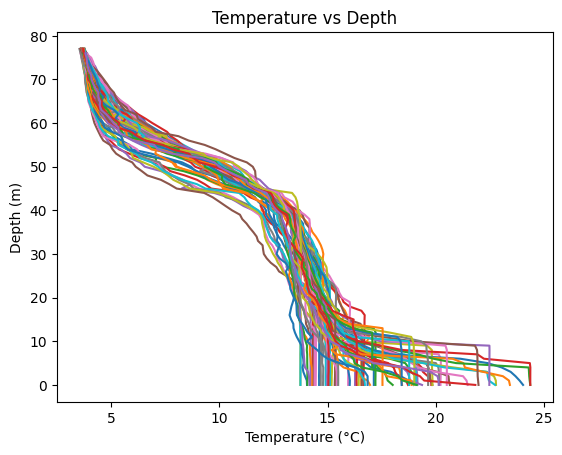

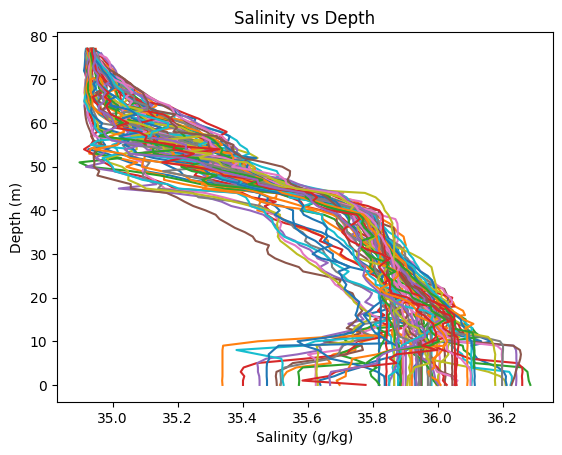

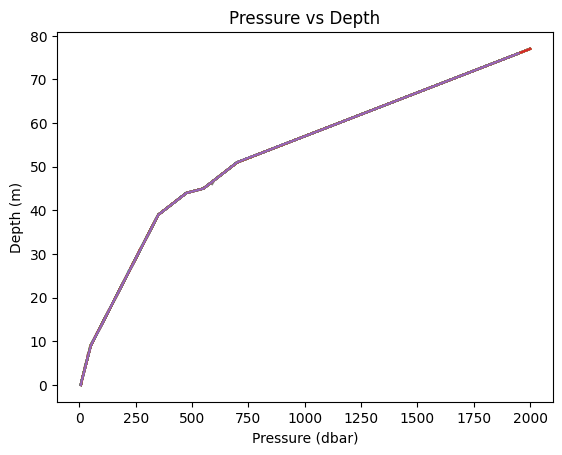

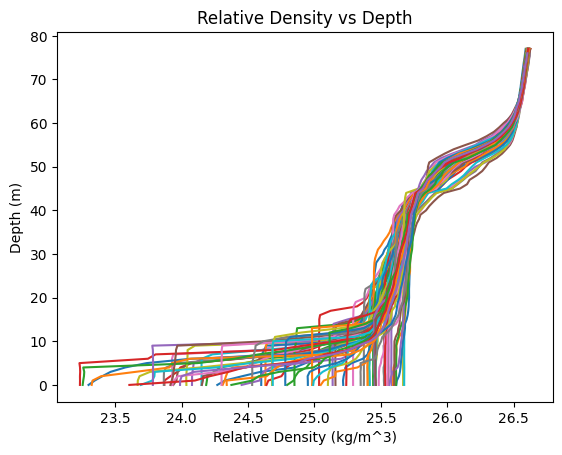

In [32]:
# Your solution here
#Temperature plot
plt.figure()
plt.plot(T, level);
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("Temperature vs Depth")
plt.show()


#Salinity Plot
plt.figure()
plt.plot(S, level);
plt.xlabel("Salinity (g/kg)")
plt.ylabel("Depth (m)")
plt.title("Salinity vs Depth")
plt.show()

#Pressure plot
plt.figure()
plt.plot(P, level);
plt.xlabel("Pressure (dbar)")
plt.ylabel("Depth (m)")
plt.title("Pressure vs Depth")
plt.show()

#Relative density plot
plt.figure()
plt.plot(relative_density, level);
plt.xlabel("Relative Density (kg/m^3)")
plt.ylabel("Depth (m)")
plt.title("Relative Density vs Depth")
plt.show()
# Hint: plt.figure() before each variable's plot, plt.show() after it
# Hint: plt.plot(S, level) draws one line per column of S
# Hint: the semicolon at the end of a plt.plot call suppresses the list of line objects
# Hint: plt.xlabel, plt.ylabel and plt.title each take a string

**Step 10.** Now plot only the *mean* profile of each variable, with the standard deviation as
error bars.

Use the NaN-aware mean and standard deviation from Step 6, and draw them with `plt.errorbar`.
Because the variable is on the *x*-axis, the spread is a *horizontal* error bar — the keyword is
`xerr`, not `yerr`.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-mean-profiles.png" alt="A single mean salinity profile against depth level with horizontal error bars at each level" width="500">

<em>The salinity panel again, reduced from 75 profiles to one line and its spread.</em>


In a comment, say what the width of the error bars tells you about how much the profiles disagree
near the surface compared with at depth.

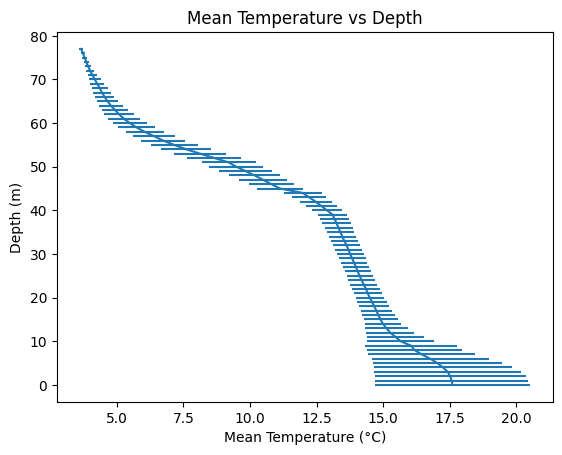

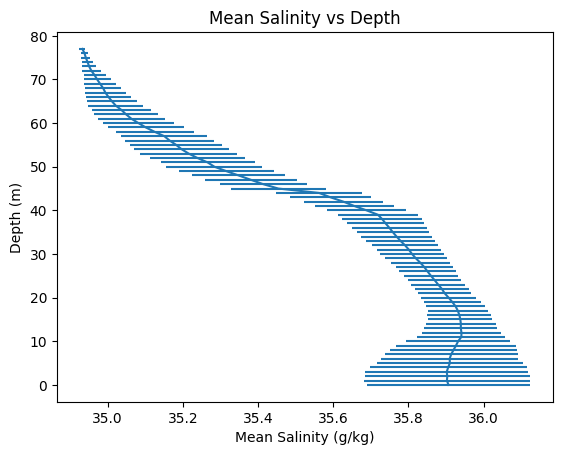

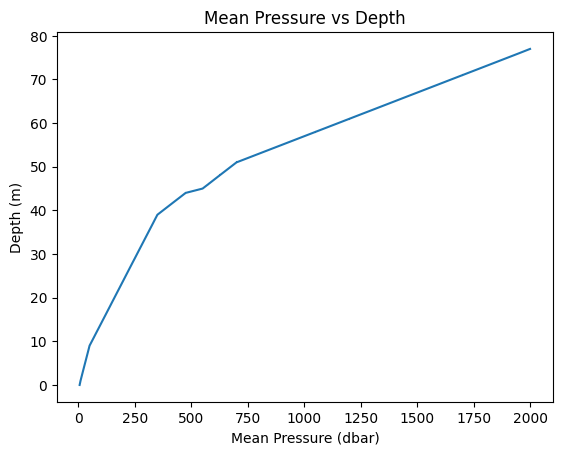

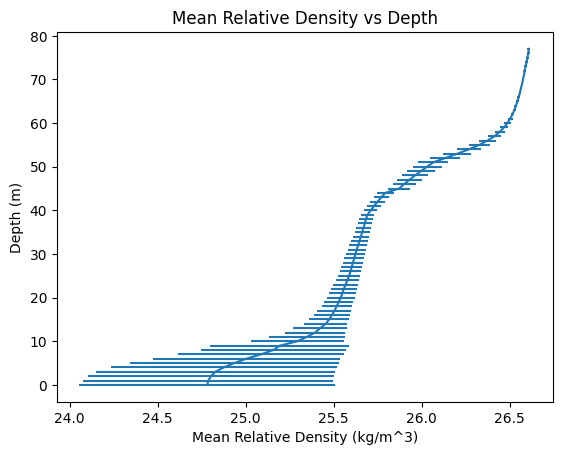

In [39]:
# Your solution here
# Hint: plt.errorbar(mean_S, level, xerr=std_S)
#temperature
plt.figure()
plt.errorbar(nan_mean_T, level, xerr=nan_std_T)
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("Mean Temperature vs Depth")
plt.show()

#salinity
plt.figure()
plt.errorbar(nan_mean_S, level, xerr=nan_std_S)
plt.xlabel("Mean Salinity (g/kg)")
plt.ylabel("Depth (m)")
plt.title("Mean Salinity vs Depth")
plt.show()

#pressure
plt.figure()
plt.errorbar(nan_mean_P, level, xerr=nan_std_P)
plt.xlabel("Mean Pressure (dbar)")
plt.ylabel("Depth (m)")
plt.title("Mean Pressure vs Depth")
plt.show()

#relative density
plt.figure()
plt.errorbar(nan_mean_rho, level, xerr=nan_std_rho)
plt.xlabel("Mean Relative Density (kg/m^3)")
plt.ylabel("Depth (m)")
plt.title("Mean Relative Density vs Depth")

plt.show()
# Hint: plt.errorbar(mean_S, level, xerr=std_S)

# Hint: use the nan-aware versions from Step 6, or every bar will be missing

**Step 11.** Scatter the profiles' longitudes against their latitudes.

One point per profile. Label both axes and give it a title, and set the marker size with `s=` so
the points are readable. Then print the first three entries of `date` and the last one.

In a comment, say what the dates and the shape of the cloud tell you about how this set of
profiles was collected, and by how many floats.

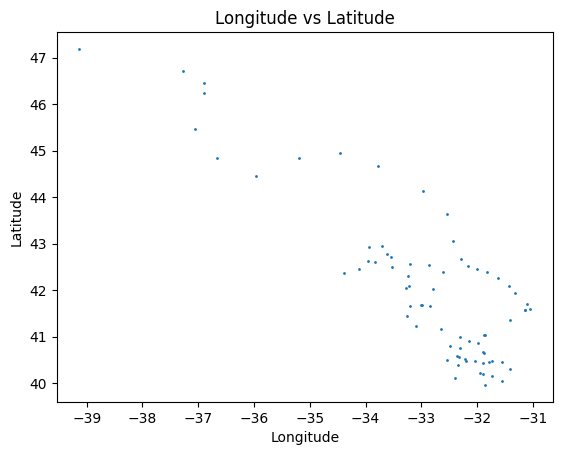

First three dates:
['2012-07-13T22:33:06.019200000' '2012-07-23T22:54:59.990400000'
 '2012-08-02T22:55:52.003200000']
Last date:
2014-07-24T03:02:33.014400000


In [41]:
# Your solution here
# Hint: plt.scatter(lon, lat)

plt.figure()
plt.scatter(lon,lat, s=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Longitude vs Latitude")
plt.show()

print("First three dates:")
print(date[:3])
print("Last date:")
print(date[-1])
#
# Hint: lon and lat have one entry per profile, not per level
# Hint: look at the spacing between consecutive dates

**ℹ️ What you just did**

You loaded a real oceanographic dataset, worked out its structure from the array shapes alone,
rebuilt a coordinate axis and verified it, evaluated a published equation of state as one
vectorised expression over 5,850 measurements (78 depth levels by 75 profiles), reduced along the
right axis, counted the missing values and switched to NaN-aware statistics, and saved a derived
product.

None of the computation needed a loop over the data. In the next subchapter `xarray` attaches the
names (depth, profile, latitude) to the axes you have been tracking by hand, and `matplotlib` gets
its full treatment, including the line, error-bar and scatter plots you drew here.